In [45]:
import numpy as np
import scipy as sp
from scipy.special import j1
import time
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from matplotlib import cm
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import axes3d
%pylab inline
figsize(11, 11)
import pickle

import sys
sys.path.insert(0,"../source/")


#from ../source/Atmospheric_Propagation import Atmospheric_Propagation
from Variational_Equations import Variational_Equations


def errorCal(field,stepSizeX,stepSizeY):
    energy = np.trapz(np.trapz(np.abs(field)**2.0,dx=stepSizeX),dx=stepSizeY)
    return energy



def figsize(scale):
    fig_width_pt = 469.755                          # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [fig_width,fig_height]
    return fig_size

pgf_with_latex = {                      # setup matplotlib to use latex for output
    "pgf.texsystem": "pdflatex",        # change this if using xetex or lautex
    "text.usetex": True,                # use LaTeX to write all text
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots to inherit fonts from the document
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 18,               # LaTeX default is 10pt font.
    "text.fontsize": 18,
    "legend.fontsize":18,               # Make the legend/label fonts a little smaller
    "xtick.labelsize":18,
    "ytick.labelsize":18,
    "figure.figsize": figsize(0.9),     # default fig size of 0.9 textwidth
    "pgf.preamble": [
        r"\usepackage[utf8x]{inputenc}",    # use utf8 fonts becasue your computer can handle it :)
        r"\usepackage[T1]{fontenc}",        # plots will be generated using this preamble
        r"\usepackage{gensymb}",
        r"\usepackage{amsmath,amssymb,amsfonts,fixmath}"
        ]
    }
mpl.rcParams.update(pgf_with_latex)


# I make my own newfig and savefig functions
def newfig(width):
    plt.clf()
    fig = plt.figure(figsize=figsize(width))
    ax = fig.add_subplot(111)
    return fig, ax

def savefig(filename):
    plt.savefig('{}.pgf'.format(filename))
    plt.savefig('{}.pdf'.format(filename))
    
    
    

Populating the interactive namespace from numpy and matplotlib


/Users/dcargill/anaconda/lib/python3.6/site-packages/IPython/core/magics/pylab.py:161: UserWarning: pylab import has clobbered these variables: ['savefig', 'figsize']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"
/Users/dcargill/anaconda/lib/python3.6/site-packages/matplotlib/__init__.py:913: UserWarning: text.fontsize is deprecated and replaced with font.size; please use the latter.
  warnings.warn(self.msg_depr % (key, alt_key))


In [2]:

## Define Dimensional Parameter Values
# codeName             # Value                   # (symbol) [char. value] <units>
#----------------------------------------------------------------------------------------------
waveLength             = 1e-6                    # (lambda) [10^{-6}]          <meters>
waveNumber             = (2.0*np.pi)/waveLength  # (lambda) [10^{6}]           <meters^{-1}>
innerScale             = 1e-2                    # (l_0)    [10^{-3}]          <meters>
outerScale             = 10                       # (L_0)    [10^{3}]           <meters>
indexStructureConstant = 5e-10                    # (C_n)    [10^{-10},10^{-6}] <meters^{-1/3}>
indexVarianceScaling   = 1                       # C_0
apertureDiameter       = 0.1                     # (D_{i})  [1 - .1]           <meters>
propagationDistance    = 5e2                    # (L)      [10^{3} - 10^{4}]  <meters> 
lengthX                = 0.5                     # XLength x_max               <meters>
lengthY                = 0.5                     # YLength y_max               <meters>
backgroundIndex        = 1.0 + 1e-6              # n_0      [1+e-6]

#alphaTarget = 5
#gamma2Target = 25
#gammaTarget  = np.sqrt(gamma2Target)
#transverseCharacteristicLength  = (2.0**(1/4) * gammaTarget) / (waveNumber * indexStructureConstant**(1/2) * outerScale**(1/6))
#propagationCharacteristicLength = (transverseCharacteristicLength**2.0) * waveNumber/alphaTarget

transverseCharacteristicLength  = innerScale
propagationCharacteristicLength = outerScale

## Define Dimensional Parameter Values
# codeName             # Value                   # (symbol) [char. value] <units>
#----------------------------------------------------------------------------------------------
numberOfPointsX                   = 512
numberOfPointsY                   = 512
numberOfPointsZ                   = 256
#numberOfInformationBlocks         = 3
#numberOfZStepsPerInformationBlock = 6
initialFieldIdentifier            = 'lagra'


In [3]:
lagSim = Variational_Equations(1,'output.txt',
                     waveLength,
                      innerScale,
                      outerScale,
                      indexStructureConstant,
                      indexVarianceScaling,
                      backgroundIndex, 
                      apertureDiameter,
                      lengthX, 
                      numberOfPointsX,
                      lengthY, 
                      numberOfPointsY,
                      propagationDistance,
                      numberOfPointsZ,
                      transverseCharacteristicLength,
                      propagationCharacteristicLength,                                
                      initialFieldIdentifier)

largest negative eigenvalue: 884.089009914


In [4]:
lagSim.RungeKutta4()


-0.0992643168685 0.409465202772
0.0831620167109 0.320341983213
0.0811426323354 0.324384805162
-0.12588000774 -0.395357460659
Finshed step  1  of  256
-0.125261309954 -0.395272312241
-0.272637618207 0.130560723901
-0.271497033572 0.130263275433
-0.0934262450965 0.000159807857117
Finshed step  2  of  256
-0.0932459096609 -0.00046829465772
0.625882584088 -0.482594103894
0.625242103355 -0.482726762763
0.525220969418 -0.387426872477
Finshed step  3  of  256
0.527136931723 -0.38783289814
-0.0466870270446 -0.0516088777878
-0.0464733559226 -0.0529464083501
0.121952001101 -0.240208653579
Finshed step  4  of  256
0.122571690349 -0.240655105789
-0.212554221585 0.160895231912
-0.213636144578 0.161166987695
0.186339018991 0.651357963821
Finshed step  5  of  256
0.186611765438 0.651726673737
0.112107682825 0.142354383831
0.115962761076 0.141804658519
-0.541354362144 -0.211503513617
Finshed step  6  of  256
-0.54090441471 -0.212181545021
0.331962055077 -0.76129895036
0.334796604121 -0.761551768444
0.

-0.2678044927 0.378844580431
-0.268157282883 0.378091201493
0.132716873387 0.230224297814
Finshed step  55  of  256
0.13213533745 0.229627398553
-0.0921845300508 0.086286882995
-0.0909916796332 0.0872329400079
0.293528128625 0.0667957810394
Finshed step  56  of  256
0.293002259945 0.0670301377799
0.0167040768599 -0.140118649893
0.0193309462088 -0.139409440093
0.380933150232 0.119490449782
Finshed step  57  of  256
0.379848175992 0.119415546659
-0.158711073429 0.0371002534562
-0.154750556667 0.0384739328085
-0.100712150622 0.263383024522
Finshed step  58  of  256
-0.0994986110374 0.263596280474
-0.192881178519 0.0425717632154
-0.192419534323 0.0408486588343
-0.0732311036153 0.425590644849
Finshed step  59  of  256
-0.072712542465 0.426635956237
-0.218958136072 -0.076657113963
-0.217679150269 -0.074017784621
0.270183019808 0.231598402205
Finshed step  60  of  256
0.268298164259 0.231406202734
0.365573376912 -0.128240685212
0.366076220313 -0.128549226912
-0.255404544815 0.349341997775
Fin

-0.342956196312 -0.0197456172694
-0.34308999638 -0.0215041158206
-0.191014543831 0.460858115069
Finshed step  110  of  256
-0.190853475187 0.459345447352
-0.0474059889743 0.388375790563
-0.0480352564283 0.392977405022
-0.309289601154 0.126734411403
Finshed step  111  of  256
-0.310099400173 0.12631606922
0.0195646015895 0.264364734909
0.0181248851269 0.263521323018
0.323170590351 0.0912830649861
Finshed step  112  of  256
0.324486437301 0.0914666320579
-0.615705049983 -0.324375334513
-0.620505621604 -0.325676271657
0.305638851974 0.364868296266
Finshed step  113  of  256
0.310518375176 0.365982403917
0.0337165732369 0.12471216566
0.0330623582579 0.126555428665
0.0878549435318 0.260353696688
Finshed step  114  of  256
0.0883110082603 0.260194720941
0.0459973655975 0.174144423197
0.0464294395942 0.173977400074
-0.449418688868 0.0672580218483
Finshed step  115  of  256
-0.44940088223 0.0669937317711
0.207001552671 -0.216237242895
0.20773600307 -0.217267630392
0.596044799476 0.364199962905

0.696944733066 0.521605438799
0.511680458208 0.0794381907341
0.507961098139 0.07848003756
0.284876671657 -0.1293748483
Finshed step  165  of  256
0.286007187789 -0.129096898169
-0.374197409048 0.157703552034
-0.372868218196 0.158350458293
-0.0670724006622 0.605742426215
Finshed step  166  of  256
-0.0673421450978 0.603432838105
-0.675993385461 -0.293460775522
-0.676962659388 -0.299859197471
0.0129054868471 -0.748989497939
Finshed step  167  of  256
0.0087375532415 -0.751506688265
-0.318769337973 0.0258526402611
-0.317617028162 0.0249623831224
0.03046439256 -0.0465889646637
Finshed step  168  of  256
0.0339873018292 -0.0489571734438
-0.332301872281 0.463698922842
-0.332291422259 0.464094664986
-0.316358944253 -0.101834478977
Finshed step  169  of  256
-0.31855136002 -0.100668654443
-0.467333004161 0.222047692219
-0.466679756 0.220541321613
-0.164179237315 0.258513404076
Finshed step  170  of  256
-0.163236525222 0.259444352147
0.00492587635225 0.476403221433
0.0050820103711 0.4765770594

0.344148198482 0.142043184777
-0.146994047661 0.796967007275
Finshed step  220  of  256
-0.146099540982 0.79730637809
-0.102146149225 0.267491606682
-0.103005628685 0.258605168353
-0.366179648143 -0.0384961574167
Finshed step  221  of  256
-0.365731885821 -0.0383163283783
0.0119040734382 0.836087421022
0.00980867230542 0.837177480526
0.264196356814 -0.0502646135063
Finshed step  222  of  256
0.263082451479 -0.0436395447491
-0.0260501643355 -0.21794027127
-0.0257662926223 -0.217332095841
0.290612519699 0.0790237125878
Finshed step  223  of  256
0.290840827729 0.078982325193
0.265944925241 -0.182314590329
0.266097178069 -0.183610251276
-0.23375522023 -0.301702153241
Finshed step  224  of  256
-0.232774265771 -0.303796196792
0.249517131446 0.398546412464
0.249004379685 0.400080875007
0.378031702208 0.0888365915504
Finshed step  225  of  256
0.376490367146 0.0844455474202
-0.657893402137 0.256913858594
-0.655830156573 0.257330015062
-0.0796158792533 0.341494846178
Finshed step  226  of  25

In [ ]:
    filename = 'Lagrangian_numberOfPointsZ-'+str(numberOfPointsZ)+'.pkl'
    fileObject = open(filename, 'wb') 
    pickle.dump([lagSim.stepSizeX,\
                 lagSim.meshPointsX,\
                 lagSim.stepSizeY, \
                 lagSim.meshPointsY, \
                 lagSim.simulatedField[:,:,numberOfPointsZ]], \
                fileObject, \
                pickle.HIGHEST_PROTOCOL)
    fileObject.close()

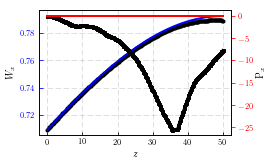

In [5]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(0.6)

ax1.plot(lagSim.pointsZ, lagSim.widthX, marker='o',markersize=3,c='k',label='Sim Width')   
ax1.plot(lagSim.pointsZ, lagSim.exactWidthX,linewidth=2,c='b',label='Exact Width')   
ax1.tick_params('y', colors='b')
ax1.set_ylabel('$W_x$')

ax2 = ax1.twinx()
ax2.plot(lagSim.pointsZ, lagSim.positionX,marker='s',markersize=3,c='k',label='Sim Position')   
ax2.plot(lagSim.pointsZ, lagSim.exactPositionX,linewidth=2,c='r',label='Exact Position')   
ax2.set_ylabel('P_x')
ax2.tick_params('y', colors='r')
#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
#ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('widthX_Rel')

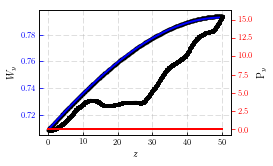

In [6]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(0.6)

ax1.plot(lagSim.pointsZ, lagSim.widthY, marker='o',markersize=3,c='k',label='Sim Width')   
ax1.plot(lagSim.pointsZ, lagSim.exactWidthY,linewidth=2,c='b',label='Exact Width')   
ax1.tick_params('y', colors='b')
ax1.set_ylabel('$W_y$')

ax2 = ax1.twinx()
ax2.plot(lagSim.pointsZ, lagSim.positionY,marker='s',markersize=3,c='k',label='Sim Position')   
ax2.plot(lagSim.pointsZ, lagSim.exactPositionY,linewidth=2,c='r',label='Exact Position')   
ax2.set_ylabel('P_y')
ax2.tick_params('y', colors='r')
#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
#ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('widthY_Exact')

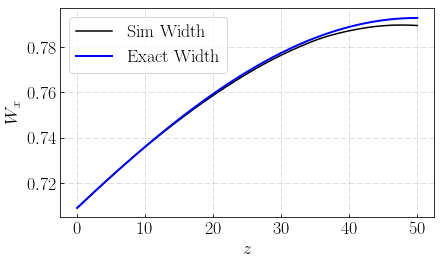

In [54]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.widthX,c='k',label='Sim Width')   
ax1.plot(lagSim.pointsZ, lagSim.exactWidthX,linewidth=2,c='b',label='Exact Width')   
ax1.set_ylabel('$W_x$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

#savefig('widthX_Ext')
savefig('widthX_Rel')

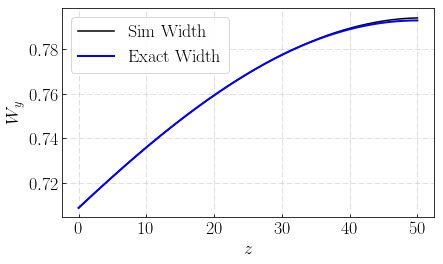

In [55]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.widthY,c='k',label='Sim Width')   
ax1.plot(lagSim.pointsZ, lagSim.exactWidthY,linewidth=2,c='b',label='Exact Width')   
ax1.set_ylabel('$W_y$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('widthY_Rel')

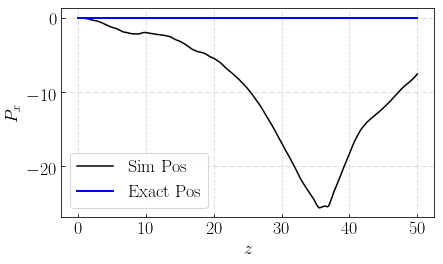

In [56]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.positionX,c='k',label='Sim Pos')   
ax1.plot(lagSim.pointsZ, lagSim.exactPositionX,linewidth=2,c='b',label='Exact Pos')   
ax1.set_ylabel('$P_x$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('positionX_Rel')

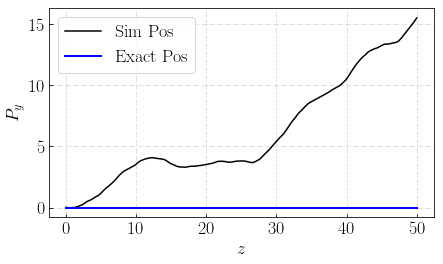

In [57]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.positionY,c='k',label='Sim Pos')   
ax1.plot(lagSim.pointsZ, lagSim.exactPositionY,linewidth=2,c='b',label='Exact Pos')   
ax1.set_ylabel('$P_y$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('positionY_Rel')

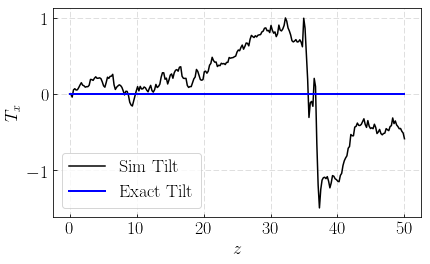

In [62]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.tiltX,c='k',label='Sim Tilt')   
ax1.plot(lagSim.pointsZ, lagSim.exactTiltX,linewidth=2,c='b',label='Exact Tilt')   
ax1.set_ylabel('$T_x$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('tiltX_Rel')

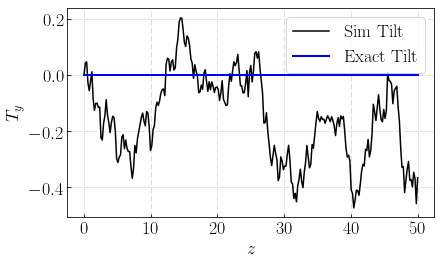

In [63]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.tiltY,c='k',label='Sim Tilt')   
ax1.plot(lagSim.pointsZ, lagSim.exactTiltY,linewidth=2,c='b',label='Exact Tilt')   
ax1.set_ylabel('$T_y$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('tiltY_Rel')

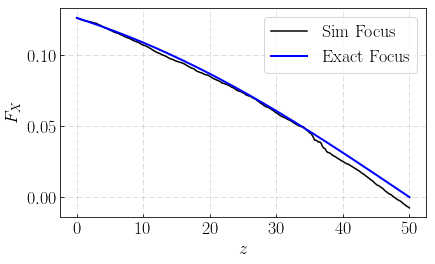

In [64]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.focusX,c='k',label='Sim Focus')   
ax1.plot(lagSim.pointsZ, lagSim.exactFocusX,linewidth=2,c='b',label='Exact Focus')   
ax1.set_ylabel('$F_X$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('focusX_Rel')

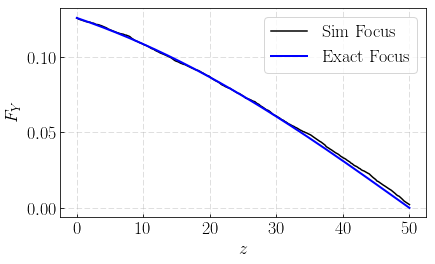

In [65]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

ax1.plot(lagSim.pointsZ, lagSim.focusY,c='k',label='Sim Focus')   
ax1.plot(lagSim.pointsZ, lagSim.exactFocusY,linewidth=2,c='b',label='Exact Focus')   
ax1.set_ylabel('$F_Y$')

#ax2.legend()

#ax1.set_title('Kolmogorov Tubulence Correlation Function')
ax1.set_xlabel('$z$')
ax1.legend()
ax1.grid(which='major', alpha=0.5,linestyle='--')  
ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')

fig.tight_layout()

    
savefig('focusY_Rel')

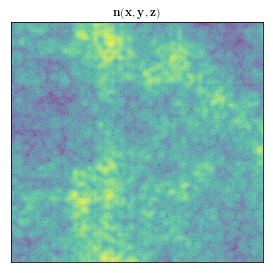

In [14]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(0.6)

cont = ax1.contourf(lagSim.meshPointsX,lagSim.meshPointsY,lagSim.indexRealizations[:,:,0],100,linewidth=0, antialiased=True)
                        
ax1.set_xticks([])  

ax1.set_yticks([])   

ax1.set_title('$\mathbf{n(x,y,z)}$')


fig.tight_layout()

    
savefig('Index_realization')

In [ ]:
mpl.rcParams['legend.fontsize'] = 10

fig = plt.figure(figsize=figsize(5))
ax = fig.gca(projection='3d')

ax.plot(lagSim.widthY, lagSim.positionY, lagSim.pointsZ, label='parametric curve')
ax.plot(lagSim.exactWidthY, lagSim.exactPositionY, lagSim.pointsZ, label='parametric curve')

ax.legend()

plt.show()

In [ ]:
lagSim.exactFocusX[0]-lagSim.focusX[0]

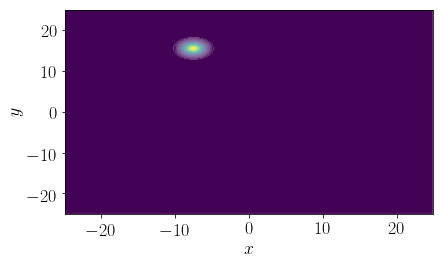

In [68]:
plt.minorticks_off()
# Simple plot
fig, ax1  = newfig(1)

cont = ax1.contourf(lagSim.meshPointsX,lagSim.meshPointsY,np.abs(lagSim.simulatedField[:,:,-1])**2,100,linewidth=0, antialiased=True)
                        
#ax1.set_xticks([])  

#ax1.set_yticks([])   

#ax1.set_title('$\mathbf{n(x,y,z)}$')

ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')

fig.tight_layout()
savefig('inital_Field')


In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(lagSim.meshPointsX, lagSim.meshPointsY, np.abs(lagSim.exactField[:,:,0])**2,100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(lagSim.meshPointsX, lagSim.meshPointsY, Sim.exactField[:,:,-1],100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
    filename = 'SplitStep4Exact_numberOfPointsZ-'+str(numberOfPointsZ)+'.pkl'
    
    fileObject = open(filename, 'wb') 
    
    sim = Paraxial_Equation(waveLength,
                      innerScale,
                      outerScale,
                      indexStructureConstant,
                      indexVarianceScaling,
                      backgroundIndex, 
                      apertureDiameter,
                      lengthX, 
                      numberOfPointsX,
                      lengthY, 
                      numberOfPointsY,
                      propagationDistance,
                      numberOfPointsZ,
                      transverseCharacteristicLength,
                      propagationCharacteristicLength,                            
                      initialFieldIdentifier)


    sim.SplitStep4Exact(numberOfPointsZ)  
   
    
    pickle.dump([sim.stepSizeX,\
                 sim.meshPointsX,\
                 sim.stepSizeY, \
                 sim.meshPointsY, \
                 sim.recordedFieldFFTIntgrator[:,:,numberOfPointsZ]], \
                fileObject, \
                pickle.HIGHEST_PROTOCOL)
    fileObject.close()



In [ ]:
    sim = Paraxial_Equation(waveLength,
                      innerScale,
                      outerScale,
                      indexStructureConstant,
                      indexVarianceScaling,
                      backgroundIndex, 
                      apertureDiameter,
                      lengthX, 
                      numberOfPointsX,
                      lengthY, 
                      numberOfPointsY,
                      propagationDistance,
                      numberOfPointsZ,
                      transverseCharacteristicLength,
                      propagationCharacteristicLength,                            
                      initialFieldIdentifier)




In [ ]:
    sim.SplitStep4Exact(numberOfPointsZ)  

In [ ]:
 onestep = sim.FFTIntegratorExact(sim.recordedFieldFFTIntgrator[:,:,0],sim.stepSizeZ)

In [ ]:
zeroEnergy = sim.Energy(sim.recordedFieldFFTIntgrator[:,:,0])

In [ ]:
zeroEnergy

In [ ]:
error = np.empty(numberOfPointsZ+1,dtype=np.float64)
for index in range(numberOfPointsZ+1):
    error[index] = errorCal(lagSim.simulatedField[:,:,index]-sim.recordedFieldFFTIntgrator[:,:,index],sim.stepSizeX,sim.stepSizeY)

In [ ]:
plt.plot(sim.pointsZ,error)

In [ ]:
sim.meshPointsY.shape

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(lagSim.meshPointsX, lagSim.meshPointsY, np.abs(lagSim.simulatedField[:,:,0]),100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(lagSim.meshPointsX, lagSim.meshPointsY, np.angle(lagSim.simulatedField[:,:,0]),100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(sim.meshPointsX, sim.meshPointsY, np.abs(sim.recordedFieldFFTIntgrator[:,:,0]),100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(sim.meshPointsX, sim.meshPointsY, np.angle(sim.recordedFieldFFTIntgrator[:,:,0]),100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
fig = plt.figure()
ax = fig.gca()

    
cont = ax.contourf(sim.meshPointsX, sim.meshPointsY, np.abs(sim.recordedFieldFFTIntgrator[:,:,0]-lagSim.simulatedField[:,:,0]),100,
                               linewidth=0, antialiased=False)
#cont = ax.contourf(paraSim.meshPointsX, paraSim.meshPointsY, paraSim.indexRealizations[:,:,32],100,
#                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)

plt.show()

In [ ]:
test = np.arange(10)+1
x = np.copy(test[1:6])
x *= 5
x += 8
print(test)


In [ ]:
laf
